#### Modules

Built on the global feature selection results, additional feature reduction was applied for each vehicle category before training the Linear Regression model.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

#### Convert categorical columns into numerical columns

In [25]:
#Upload dataset (we are not using carbon emission and fule comsumption comb as features)
df = pd.read_csv("../Data/Clean dataset.csv")
df = df.drop(columns = ['CO2 Emissions(g/km)', 'Fuel Consumption Comb (mpg)'])
vehicle_class_map = {
    "MINICOMPACT": "SMALL",
    "SUBCOMPACT": "SMALL",
    "COMPACT": "SMALL",
    "TWO-SEATER": "SMALL",

    "STATION WAGON - SMALL": "MIDDLE",
    "MID-SIZE": "MIDDLE",
    "FULL-SIZE": "MIDDLE",

    "SUV - SMALL": "VAN",
    "SUV - STANDARD": "VAN",
    "STATION WAGON - MID-SIZE": "VAN",

    "PICKUP TRUCK - SMALL": "LARGE",
    "PICKUP TRUCK - STANDARD": "LARGE",
    "VAN - CARGO": "LARGE",
    "VAN - PASSENGER": "LARGE",
    "MINIVAN": "LARGE",
    "SPECIAL PURPOSE VEHICLE": "LARGE"
}

df["Type"] = df["Vehicle Class"].map(vehicle_class_map).fillna("Other")
df = df.drop(columns=['Vehicle Class'])

# Specical case for transmission (e.g. Separate AS5 to AS and 5, 5 stored as gear number for the car, for AV gear number will be zero)
df['Transmission Type'] = df['Transmission'].str.extract(r'([A-Za-z]+)')
df['Gear num'] = df['Transmission'].str.extract(r'(\d+)').astype(float)
df = df.fillna(0)
df = df.drop(columns = ['Transmission'])


# One Hot Encoding for all categorical features
cat_cols = ['Transmission Type', 'Fuel Type']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# Rearrange column position and brief view of dataset
col1 = 'Fuel Consumption City (L/100 km)'
col2 = 'Fuel Consumption Hwy (L/100 km)'
col3 = 'Fuel Consumption Comb (L/100 km)'

col_order = [c for c in df.columns if c not in [col1, col2, col3]] + [col1, col2, col3]

df = df[col_order]
df.describe()

# Output dataset for later training
output_path = Path("../Data/Regression dataset.csv")
df.to_csv(output_path, index=False)

In [26]:
# Split dataset by vehicle type
small_df = df[df["Type"] == "SMALL"]
middle_df = df[df["Type"] == "MIDDLE"]
van_df = df[df["Type"] == "VAN"]
large_df = df[df["Type"] == "LARGE"]

#feature
feat_small = small_df.drop(columns=[
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'Type'
])

feat_middle = middle_df.drop(columns=[
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'Type'
])

feat_van = van_df.drop(columns=[
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'Type'
])

feat_large = large_df.drop(columns=[
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'Type'
])
#target
city_small = small_df['Fuel Consumption City (L/100 km)']
comb_middle = middle_df['Fuel Consumption Comb (L/100 km)']
comb_van = van_df['Fuel Consumption Comb (L/100 km)']
hwy_large = large_df['Fuel Consumption Hwy (L/100 km)']

#### Split train and test set & standardscaler features

In [27]:
# Split the data into training and testing sets (80% train, 20% test)
xs_train, xs_test, ys_tr, ys_te = train_test_split(feat_small, city_small, test_size=0.2, random_state=42)
xm_train, xm_test, ym_tr, ym_te = train_test_split(feat_middle, comb_middle, test_size=0.2, random_state=42)
xv_train, xv_test, yv_tr, yv_te = train_test_split(feat_van, comb_van, test_size=0.2, random_state=42)
xl_train, xl_test, yl_tr, yl_te = train_test_split(feat_large, hwy_large, test_size=0.2, random_state=42)
#Normalize the X data
scaler = StandardScaler()
xs_tr, xs_te = scaler.fit_transform(xs_train), scaler.transform(xs_test)
xm_tr, xm_te = scaler.fit_transform(xm_train), scaler.transform(xm_test)
xv_tr, xv_te = scaler.fit_transform(xv_train), scaler.transform(xv_test)
xl_tr, xl_te = scaler.fit_transform(xl_train), scaler.transform(xl_test)

#### Fitting the model with linear regression (adequate performance)

In [29]:
# Small vehicle model (City)
l_s = LinearRegression()
l_s.fit(xs_tr, ys_tr)

s_pred = l_s.predict(xs_te)
s_r2 = r2_score(ys_te, s_pred)
s_rmse = root_mean_squared_error(ys_te, s_pred)

print(f"R2 for small vehicle model: {s_r2}")
print(f"RMSE for small vehicle model: {s_rmse}\n")


# Midsize vehicle model (Combined)
l_m = LinearRegression()
l_m.fit(xm_tr, ym_tr)

m_pred = l_m.predict(xm_te)
m_r2 = r2_score(ym_te, m_pred)
m_rmse = root_mean_squared_error(ym_te, m_pred)

print(f"R2 for midsize vehicle model: {m_r2}")
print(f"RMSE for midsize vehicle model: {m_rmse}\n")


# SUV / Minivan model (Combined)
l_v = LinearRegression()
l_v.fit(xv_tr, yv_tr)

v_pred = l_v.predict(xv_te)
v_r2 = r2_score(yv_te, v_pred)
v_rmse = root_mean_squared_error(yv_te, v_pred)

print(f"R2 for SUV/minivan model: {v_r2}")
print(f"RMSE for SUV/minivan model: {v_rmse}\n")


# Truck / Van model (Highway)
l_l = LinearRegression()
l_l.fit(xl_tr, yl_tr)

l_pred = l_l.predict(xl_te)
l_r2 = r2_score(yl_te, l_pred)
l_rmse = root_mean_squared_error(yl_te, l_pred)

print(f"R2 for truck/van model: {l_r2}")
print(f"RMSE for truck/van model: {l_rmse}")

R2 for small vehicle model: 0.8775387771308022
RMSE for small vehicle model: 1.1197230974301422

R2 for midsize vehicle model: 0.8456067219270589
RMSE for midsize vehicle model: 1.0225343795516275

R2 for SUV/minivan model: 0.8352822422668152
RMSE for SUV/minivan model: 1.0644770237142733

R2 for truck/van model: 0.8167886793747594
RMSE for truck/van model: 1.082850192251679


lr models show good predictive performance across all vehicle categories, with R2 all above 0.8.
The **truck/van model** has the lowest R², suggesting slightly lower accuracy.

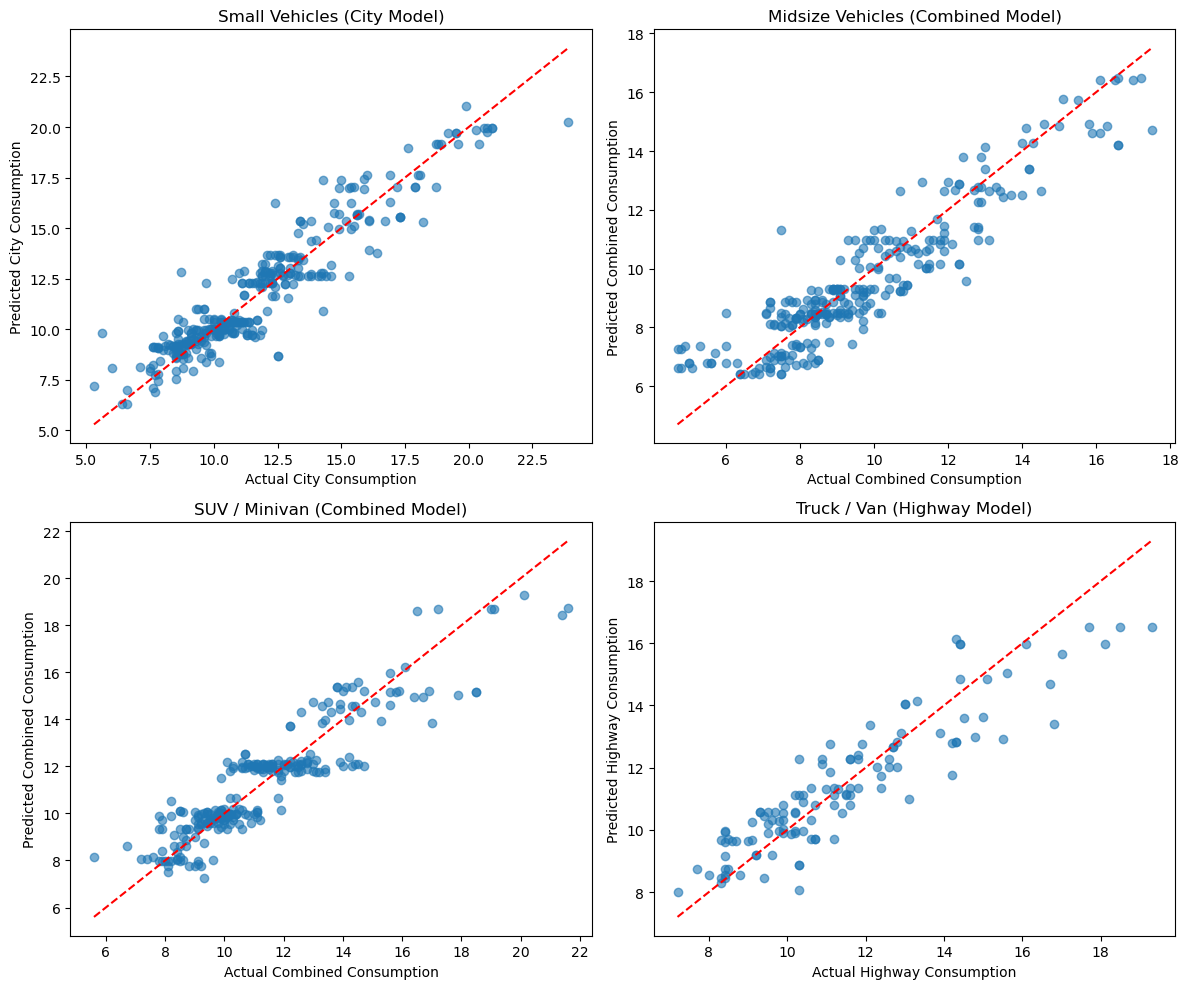

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))


# Small Vehicles (City)
axes[0,0].scatter(ys_te, s_pred, alpha=0.6)
axes[0,0].plot([ys_te.min(), ys_te.max()],
               [ys_te.min(), ys_te.max()],
               'r--')
axes[0,0].set_xlabel("Actual City Consumption")
axes[0,0].set_ylabel("Predicted City Consumption")
axes[0,0].set_title("Small Vehicles (City Model)")


# Midsize Vehicles (Combined)
axes[0,1].scatter(ym_te, m_pred, alpha=0.6)
axes[0,1].plot([ym_te.min(), ym_te.max()],
               [ym_te.min(), ym_te.max()],
               'r--')
axes[0,1].set_xlabel("Actual Combined Consumption")
axes[0,1].set_ylabel("Predicted Combined Consumption")
axes[0,1].set_title("Midsize Vehicles (Combined Model)")


# SUV / Minivan (Combined)
axes[1,0].scatter(yv_te, v_pred, alpha=0.6)
axes[1,0].plot([yv_te.min(), yv_te.max()],
               [yv_te.min(), yv_te.max()],
               'r--')
axes[1,0].set_xlabel("Actual Combined Consumption")
axes[1,0].set_ylabel("Predicted Combined Consumption")
axes[1,0].set_title("SUV / Minivan (Combined Model)")


# Truck / Van (Highway)
axes[1,1].scatter(yl_te, l_pred, alpha=0.6)
axes[1,1].plot([yl_te.min(), yl_te.max()],
               [yl_te.min(), yl_te.max()],
               'r--')
axes[1,1].set_xlabel("Actual Highway Consumption")
axes[1,1].set_ylabel("Predicted Highway Consumption")
axes[1,1].set_title("Truck / Van (Highway Model)")


plt.tight_layout()
plt.show()

**Residual Behaviour and Model Assumptions**

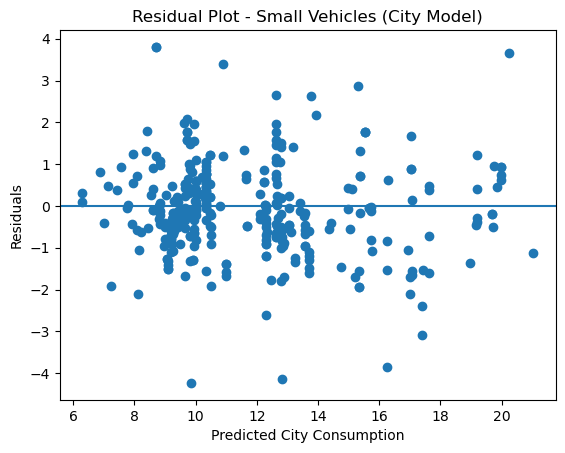

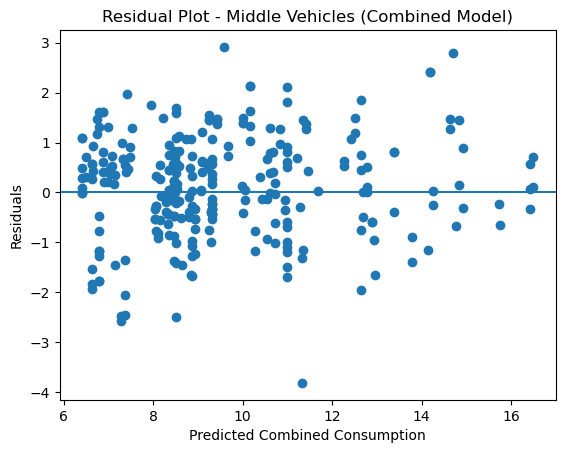

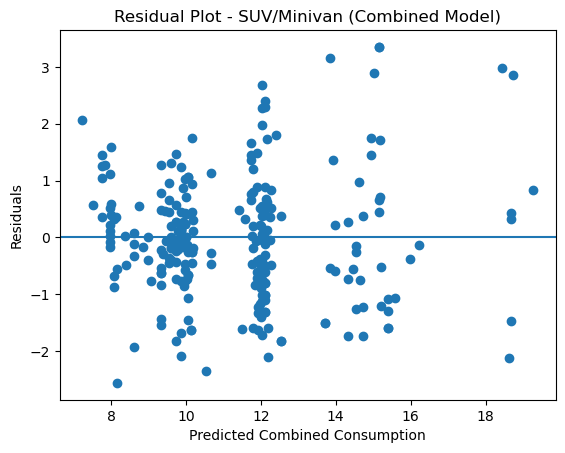

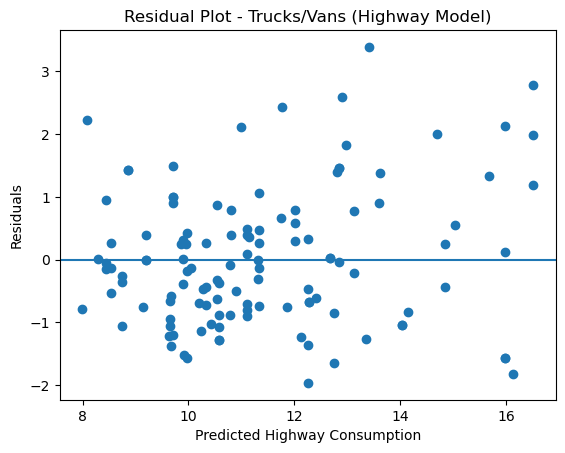

In [31]:
# Residuals calculation
residuals_small = ys_te - s_pred
residuals_middle = ym_te - m_pred
residuals_van = yv_te - v_pred
residuals_large = yl_te - l_pred


# Small Vehicles Residual Plot (City)
plt.figure()
plt.scatter(s_pred, residuals_small)
plt.axhline(0)
plt.xlabel("Predicted City Consumption")
plt.ylabel("Residuals")
plt.title("Residual Plot - Small Vehicles (City Model)")
plt.show()


# Middle Vehicles Residual Plot (Combined)
plt.figure()
plt.scatter(m_pred, residuals_middle)
plt.axhline(0)
plt.xlabel("Predicted Combined Consumption")
plt.ylabel("Residuals")
plt.title("Residual Plot - Middle Vehicles (Combined Model)")
plt.show()


# Van Residual Plot (Combined)
plt.figure()
plt.scatter(v_pred, residuals_van)
plt.axhline(0)
plt.xlabel("Predicted Combined Consumption")
plt.ylabel("Residuals")
plt.title("Residual Plot - SUV/Minivan (Combined Model)")
plt.show()


# Large Vehicles Residual Plot (Highway)
plt.figure()
plt.scatter(l_pred, residuals_large)
plt.axhline(0)
plt.xlabel("Predicted Highway Consumption")
plt.ylabel("Residuals")
plt.title("Residual Plot - Trucks/Vans (Highway Model)")
plt.show()

### Residual Behaviour and Model Assumptions

The residual plots for all four models show residuals randomly scattered around zero with no clear systematic patterns, indicating that the main linear regression assumptions (linearity and constant variance) are generally satisfied.


**Weights Analysis**
For linear regression, the coefficient=weight

In [32]:
#small model
coef_small = (
    pd.DataFrame({
        "Feature": xs_train.columns,
        "Weight": l_s.coef_
    })
    .assign(Importance=lambda x: np.abs(x["Weight"]))
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

coef_small

,Feature,Weight,Importance
0,Engine Size(L),1.531740e+00,1.531740e+00
1,Cylinders,1.192182e+00,1.192182e+00
2,Fuel Type_Z,1.063248e+00,1.063248e+00
3,Fuel Type_X,7.289548e-01,7.289548e-01
4,Fuel Type_E,4.586407e-01,4.586407e-01
5,Transmission Type_AM,2.859169e-01,2.859169e-01
6,Transmission Type_M,2.802310e-01,2.802310e-01
7,Transmission Type_AV,-2.291216e-01,2.291216e-01
8,Transmission Type_AS,1.036102e-01,1.036102e-01
9,Gear num,4.418341e-02,4.418341e-02


In [33]:
# middle model
coef_middle = (
    pd.DataFrame({
        "Feature": xm_train.columns,
        "Weight": l_m.coef_
    })
    .assign(Importance=lambda x: np.abs(x["Weight"]))
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

coef_middle

,Feature,Weight,Importance
0,Fuel Type_Z,1.167928,1.167928
1,Fuel Type_E,1.098631,1.098631
2,Engine Size(L),0.951990,0.951990
3,Cylinders,0.866450,0.866450
4,Fuel Type_X,0.807524,0.807524
5,Transmission Type_AV,-0.409103,0.409103
6,Transmission Type_AM,-0.174161,0.174161
7,Transmission Type_AS,0.129379,0.129379
8,Fuel Type_N,0.110585,0.110585
9,Transmission Type_M,0.079471,0.079471


In [34]:
# van model
coef_van = (
    pd.DataFrame({
        "Feature": xv_train.columns,
        "Weight": l_v.coef_
    })
    .assign(Importance=lambda x: np.abs(x["Weight"]))
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

coef_van

,Feature,Weight,Importance
0,Fuel Type_E,1.188784e+00,1.188784e+00
1,Cylinders,1.050284e+00,1.050284e+00
2,Fuel Type_Z,9.364850e-01,9.364850e-01
3,Fuel Type_X,7.687310e-01,7.687310e-01
4,Engine Size(L),7.596318e-01,7.596318e-01
5,Transmission Type_AV,-5.786352e-01,5.786352e-01
6,Gear num,-1.745457e-01,1.745457e-01
7,Transmission Type_AS,6.636565e-02,6.636565e-02
8,Transmission Type_AM,-4.592268e-02,4.592268e-02
9,Transmission Type_M,-3.142191e-02,3.142191e-02


In [35]:
# large model
coef_large = (
    pd.DataFrame({
        "Feature": xl_train.columns,
        "Weight": l_l.coef_
    })
    .assign(Importance=lambda x: np.abs(x["Weight"]))
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

coef_large

,Feature,Weight,Importance
0,Fuel Type_E,1.761965e+00,1.761965e+00
1,Engine Size(L),1.198309e+00,1.198309e+00
2,Gear num,-4.896249e-01,4.896249e-01
3,Fuel Type_X,3.398630e-01,3.398630e-01
4,Transmission Type_AS,2.234841e-01,2.234841e-01
5,Transmission Type_AV,-1.952292e-01,1.952292e-01
6,Transmission Type_M,9.009961e-02,9.009961e-02
7,Cylinders,8.551160e-02,8.551160e-02
8,Fuel Type_Z,7.810544e-02,7.810544e-02
9,Transmission Type_AM,6.661338e-16,6.661338e-16


|weight| biger → feature more important
Four models have similar results:

Fuel Type_E, Engine Size are very important.

Fuel Type_N and Transmission Type_AM could be candidates for feature elimination

#### Pearson correlation heat maps

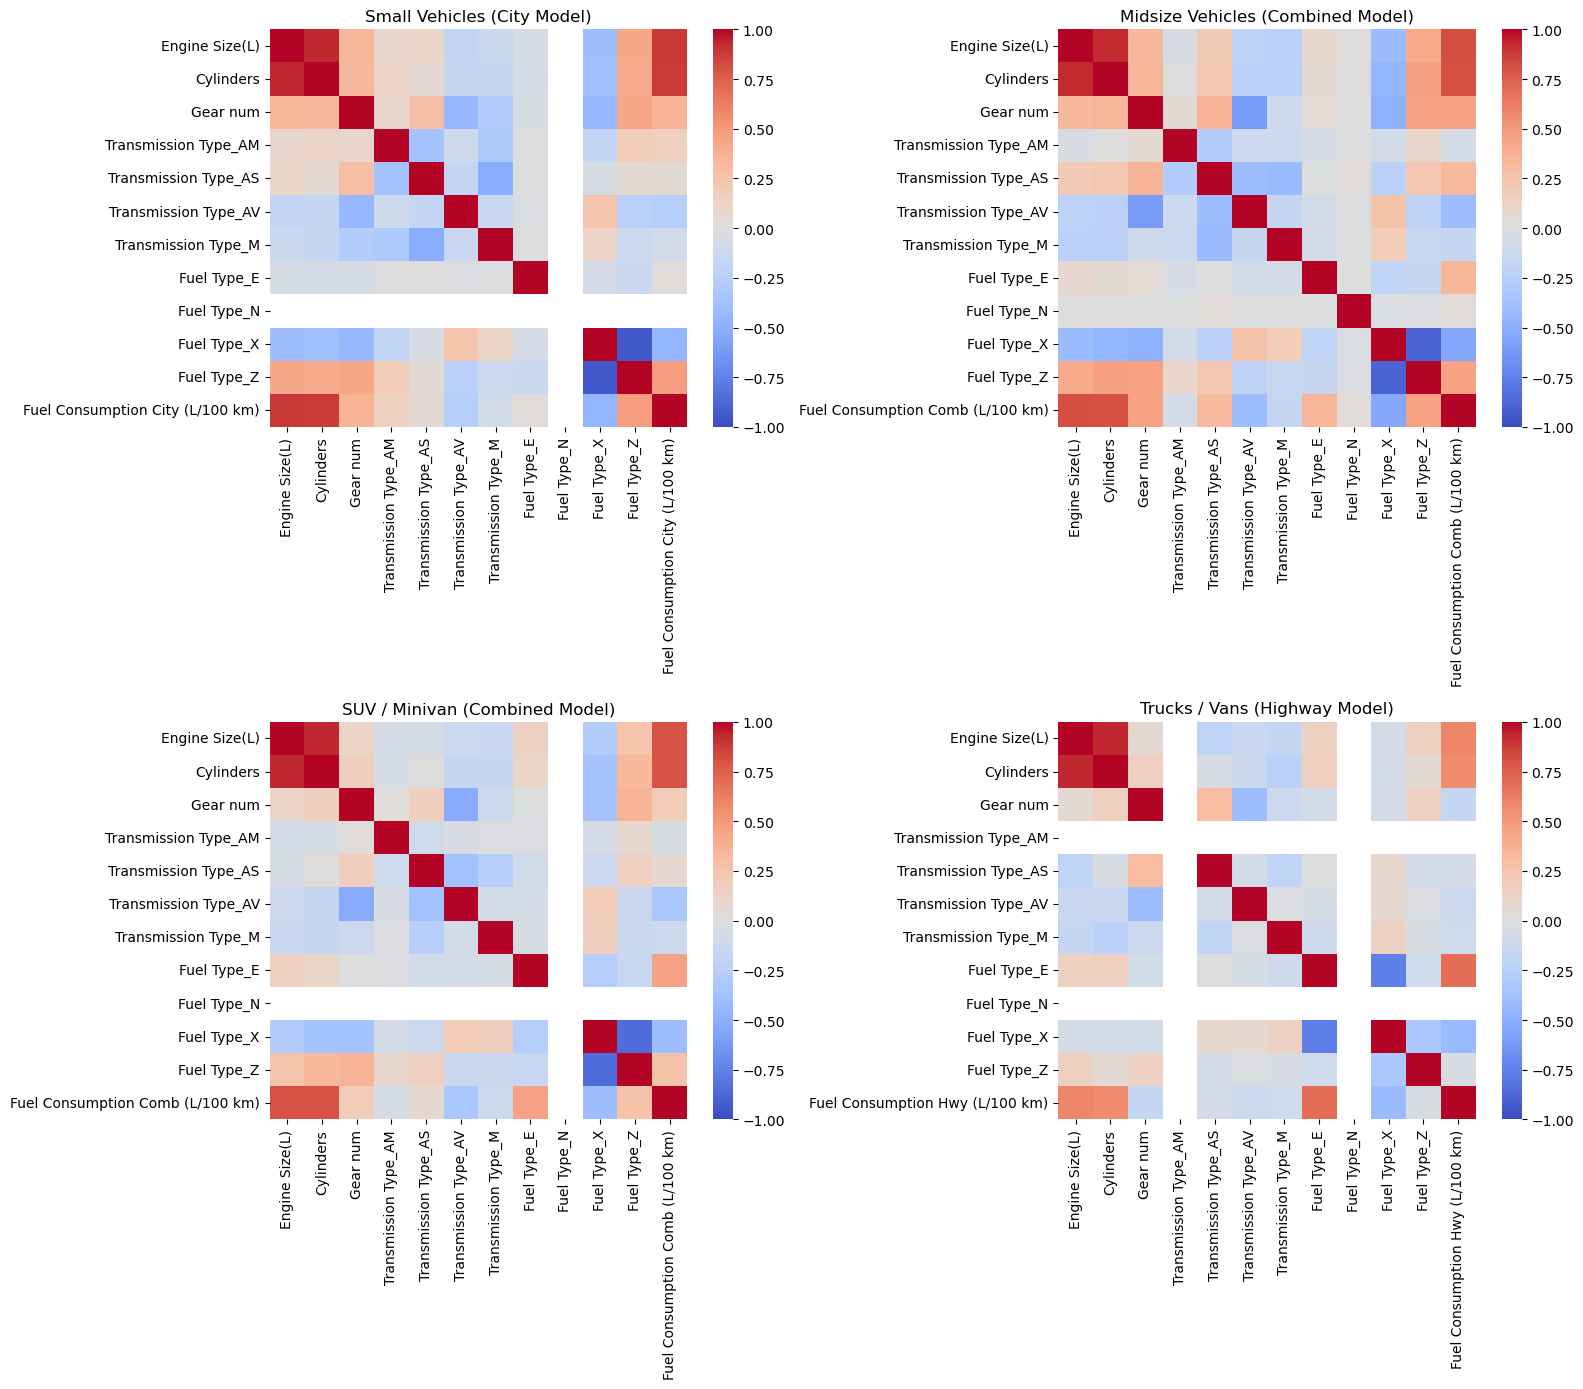

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Small Vehicles (City model)
small_corr = small_df.drop(columns=[
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)"
]).select_dtypes(include="number")

sns.heatmap(
    small_corr.corr(),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0,0]
)
axes[0,0].set_title("Small Vehicles (City Model)")


# Middle Vehicles (Combined model)
middle_corr = middle_df.drop(columns=[
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)"
]).select_dtypes(include="number")

sns.heatmap(
    middle_corr.corr(),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0,1]
)
axes[0,1].set_title("Midsize Vehicles (Combined Model)")


# SUV / Minivan (Combined model)
van_corr = van_df.drop(columns=[
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)"
]).select_dtypes(include="number")

sns.heatmap(
    van_corr.corr(),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[1,0]
)
axes[1,0].set_title("SUV / Minivan (Combined Model)")


# Trucks / Vans (Highway model)
large_corr = large_df.drop(columns=[
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Comb (L/100 km)"
]).select_dtypes(include="number")

sns.heatmap(
    large_corr.corr(),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[1,1]
)
axes[1,1].set_title("Trucks / Vans (Highway Model)")


plt.tight_layout()
plt.show()

The Pearson correlation heat maps show the pairwise linear relationships between individual features and the target variable, while the regression coefficients reflect the contribution of each feature when all variables are considered simultaneously.

Therefore, some differences between the correlation analysis and the weight analysis are expected. This is mainly due to multicollinearity among features.

Engine Size ↔ Cylinders → very high correlation

In [37]:
# Correlation with City (Small Vehicles)
print(
    f'Correlation for Small Vehicles (City):\n'
    f'{np.abs(small_df.select_dtypes(include="number").corr()["Fuel Consumption City (L/100 km)"])\
    .sort_values(ascending=False)}\n\n'
)

# Correlation with Combined (Middle Vehicles)
print(
    f'Correlation for Midsize Vehicles (Combined):\n'
    f'{np.abs(middle_df.select_dtypes(include="number").corr()["Fuel Consumption Comb (L/100 km)"])\
    .sort_values(ascending=False)}\n\n'
)

# Correlation with Combined (SUV / Minivan)
print(
    f'Correlation for SUV / Minivan (Combined):\n'
    f'{np.abs(van_df.select_dtypes(include="number").corr()["Fuel Consumption Comb (L/100 km)"])\
    .sort_values(ascending=False)}\n\n'
)

# Correlation with Highway (Trucks / Vans)
print(
    f'Correlation for Trucks / Vans (Highway):\n'
    f'{np.abs(large_df.select_dtypes(include="number").corr()["Fuel Consumption Hwy (L/100 km)"])\
    .sort_values(ascending=False)}'
)

Correlation for Small Vehicles (City):
Fuel Consumption City (L/100 km)    1.000000
Fuel Consumption Comb (L/100 km)    0.996280
Fuel Consumption Hwy (L/100 km)     0.963468
Engine Size(L)                      0.887003
Cylinders                           0.876037
Fuel Type_Z                         0.480825
Fuel Type_X                         0.461205
Gear num                            0.359643
Transmission Type_AV                0.263046
Transmission Type_AM                0.155687
Transmission Type_M                 0.090122
Transmission Type_AS                0.047287
Fuel Type_E                         0.030432
Fuel Type_N                              NaN
Name: Fuel Consumption City (L/100 km), dtype: float64


Correlation for Midsize Vehicles (Combined):
Fuel Consumption Comb (L/100 km)    1.000000
Fuel Consumption City (L/100 km)    0.996388
Fuel Consumption Hwy (L/100 km)     0.981570
Engine Size(L)                      0.817706
Cylinders                           0.812396
Fuel

#### Recursive Feature Elimination

In [38]:
lg = LinearRegression()
# cross validation to find the optimal number of features
kf = KFold(n_splits=5, shuffle=True, random_state=42)
selector = RFECV(estimator=lg, step=1, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)

#small city model
selector.fit(xs_tr, ys_tr)

cv_results_small = selector.cv_results_.copy()

sel_list_s = selector.support_
feat_rk_s = selector.ranking_
sel_feat_s = xs_train.columns[sel_list_s].to_list()

print(f'Number of features for small vehicle model: {len(xs_train.columns)}')
print(f'Selected features: {len(sel_feat_s)}\n')

print(
    pd.DataFrame({
        'Feature': xs_train.columns,
        'Ranking': feat_rk_s
    }).sort_values(by='Ranking')
)

#medium vehicle model
selector.fit(xm_tr, ym_tr)

cv_results_middle = selector.cv_results_.copy()

sel_list_m = selector.support_
feat_rk_m = selector.ranking_

sel_feat_m = xm_train.columns[sel_list_m].to_list()

print(f'\nNumber of features for middle vehicle model: {len(xm_train.columns)}')
print(f'Selected features: {len(sel_feat_m)}\n')

print(
    pd.DataFrame({
        'Feature': xm_train.columns,
        'Ranking': feat_rk_m
    }).sort_values(by='Ranking')
)

#suv/minivan model
selector.fit(xv_tr, yv_tr)

cv_results_van = selector.cv_results_.copy()

sel_list_v = selector.support_
feat_rk_v = selector.ranking_

sel_feat_v = xv_train.columns[sel_list_v].to_list()

print(f'\nNumber of features for van model: {len(xv_train.columns)}')
print(f'Selected features: {len(sel_feat_v)}\n')

print(
    pd.DataFrame({
        'Feature': xv_train.columns,
        'Ranking': feat_rk_v
    }).sort_values(by='Ranking')
)

#truck vans model
selector.fit(xl_tr, yl_tr)

cv_results_large = selector.cv_results_.copy()

sel_list_l = selector.support_
feat_rk_l = selector.ranking_

sel_feat_l = xl_train.columns[sel_list_l].to_list()

print(f'\nNumber of features for large vehicle model: {len(xl_train.columns)}')
print(f'Selected features: {len(sel_feat_l)}\n')

print(
    pd.DataFrame({
        'Feature': xl_train.columns,
        'Ranking': feat_rk_l
    }).sort_values(by='Ranking')
)

Number of features for small vehicle model: 11
Selected features: 9

                 Feature  Ranking
0         Engine Size(L)        1
1              Cylinders        1
3   Transmission Type_AM        1
4   Transmission Type_AS        1
6    Transmission Type_M        1
5   Transmission Type_AV        1
7            Fuel Type_E        1
9            Fuel Type_X        1
10           Fuel Type_Z        1
2               Gear num        2
8            Fuel Type_N        3

Number of features for middle vehicle model: 11
Selected features: 11

                 Feature  Ranking
0         Engine Size(L)        1
1              Cylinders        1
2               Gear num        1
3   Transmission Type_AM        1
4   Transmission Type_AS        1
5   Transmission Type_AV        1
6    Transmission Type_M        1
7            Fuel Type_E        1
8            Fuel Type_N        1
9            Fuel Type_X        1
10           Fuel Type_Z        1

Number of features for van model: 11
Selec

### Feature Selection Results (RFECV)

#### Small Vehicles (City Model)
**9 out of 11 features** as important predictors.  
The most relevant features include **Engine Size, Cylinders, Transmission Types, and Fuel Types (E, X, Z)**.  
The features **Gear num** and **Fuel Type_N**  contribute less to the prediction and could potentially be removed.

#### Midsize Vehicles (Combined Model)
For midsize vehicles, RFECV retained **all 11 features**, suggesting that each variable contributes useful information to the model.  

#### SUV / Minivan (Combined Model)
Similarly, the RFECV process selected **all 11 features** for the SUV / Minivan model.  

#### Trucks / Vans (Highway Model)
For trucks and vans, RFECV selected **9 out of 11 features**.  
The variables **Transmission Type_AM** and **Fuel Type_N** have relatively limited influence on highway fuel consumption for these vehicles.

 **RFECV Feature Selection Performance – City Model**

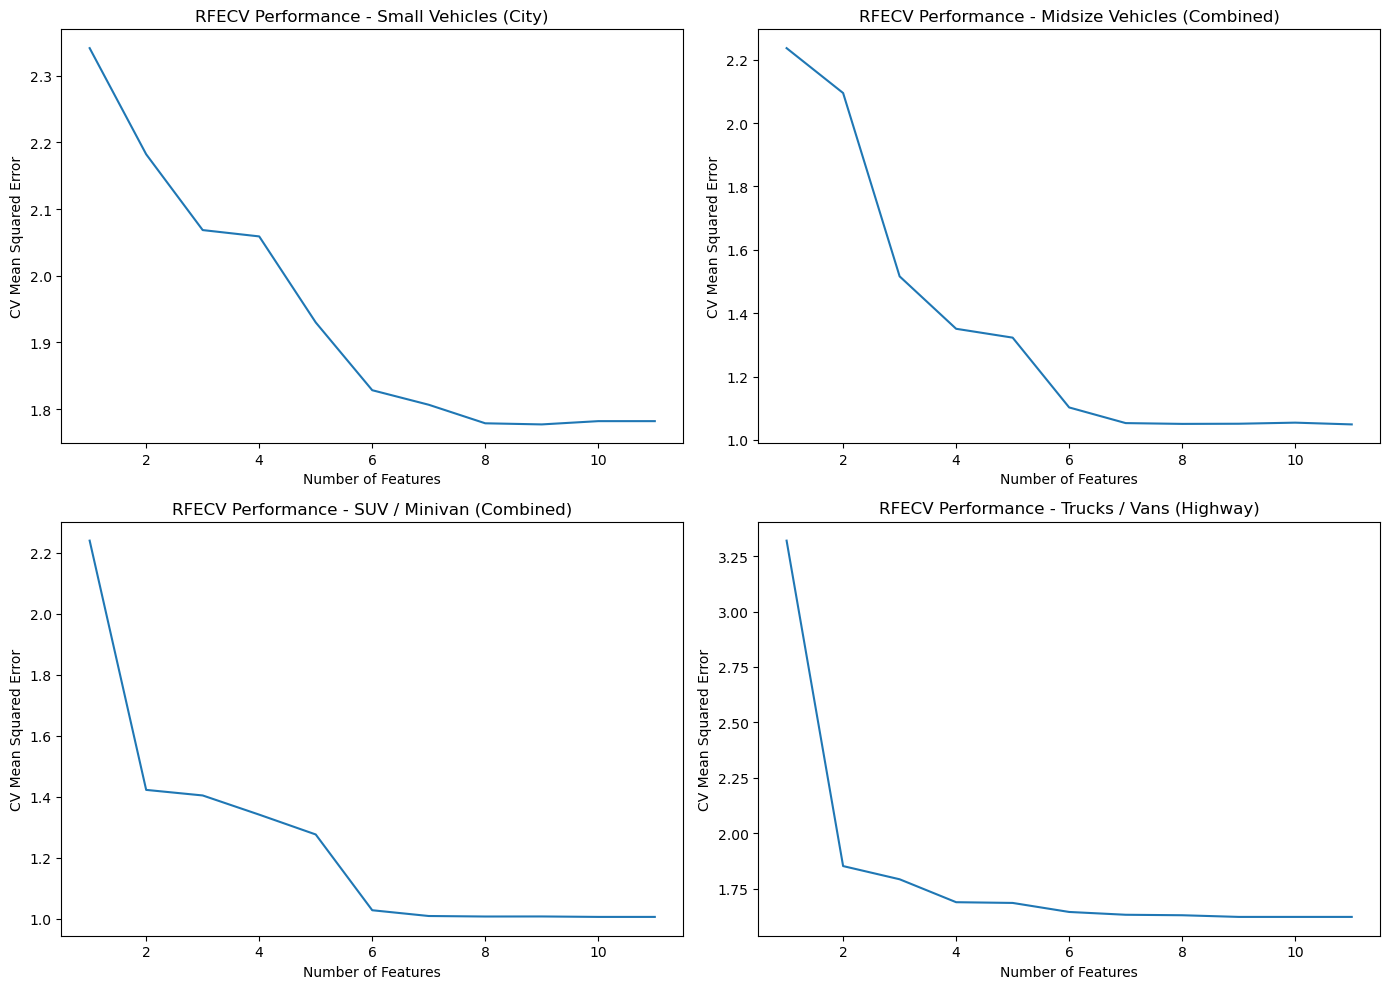

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# Small Vehicles (City Model)
axes[0,0].plot(
    range(1, len(cv_results_small["mean_test_score"]) + 1),
    -cv_results_small["mean_test_score"]
)
axes[0,0].set_xlabel("Number of Features")
axes[0,0].set_ylabel("CV Mean Squared Error")
axes[0,0].set_title("RFECV Performance - Small Vehicles (City)")


# Middle Vehicles (Combined Model)
axes[0,1].plot(
    range(1, len(cv_results_middle["mean_test_score"]) + 1),
    -cv_results_middle["mean_test_score"]
)
axes[0,1].set_xlabel("Number of Features")
axes[0,1].set_ylabel("CV Mean Squared Error")
axes[0,1].set_title("RFECV Performance - Midsize Vehicles (Combined)")


# SUV / Minivan (Combined Model)
axes[1,0].plot(
    range(1, len(cv_results_van["mean_test_score"]) + 1),
    -cv_results_van["mean_test_score"]
)
axes[1,0].set_xlabel("Number of Features")
axes[1,0].set_ylabel("CV Mean Squared Error")
axes[1,0].set_title("RFECV Performance - SUV / Minivan (Combined)")


# Trucks / Vans (Highway Model)
axes[1,1].plot(
    range(1, len(cv_results_large["mean_test_score"]) + 1),
    -cv_results_large["mean_test_score"]
)
axes[1,1].set_xlabel("Number of Features")
axes[1,1].set_ylabel("CV Mean Squared Error")
axes[1,1].set_title("RFECV Performance - Trucks / Vans (Highway)")


plt.tight_layout()
plt.show()

The RFECV curves suggest that the selected number of features is reasonable, as the model performance stabilizes when more features are included.

#### Use Lasso to find the most important feature

In [40]:
#Find the best alpha values for models
lasso_cv = LassoCV(alphas=None, cv=kf, max_iter=10000, n_jobs=-1, random_state=42)

alpha_small = lasso_cv.fit(xs_tr, ys_tr).alpha_
print(f'Best alpha for Small Vehicles (City): {alpha_small}')

alpha_middle = lasso_cv.fit(xm_tr, ym_tr).alpha_
print(f'Best alpha for Midsize Vehicles (Combined): {alpha_middle}')

alpha_van = lasso_cv.fit(xv_tr, yv_tr).alpha_
print(f'Best alpha for SUV / Minivan (Combined): {alpha_van}')

alpha_large = lasso_cv.fit(xl_tr, yl_tr).alpha_
print(f'Best alpha for Trucks / Vans (Highway): {alpha_large}\n')


# Lasso for small model
la_small = Lasso(max_iter=10000, alpha=alpha_small).fit(xs_tr, ys_tr)

s_pred_lasso = la_small.predict(xs_te)

s_r2_lasso = r2_score(ys_te, s_pred_lasso)
s_rmse_lasso = root_mean_squared_error(ys_te, s_pred_lasso)

print(f"Lasso R2 for Small Vehicles (City): {s_r2_lasso}")
print(f"Lasso RMSE for Small Vehicles (City): {s_rmse_lasso}\n")

coef_small = la_small.coef_

# Lasso for medium model
la_middle = Lasso(max_iter=10000, alpha=alpha_middle).fit(xm_tr, ym_tr)

m_pred_lasso = la_middle.predict(xm_te)

m_r2_lasso = r2_score(ym_te, m_pred_lasso)
m_rmse_lasso = root_mean_squared_error(ym_te, m_pred_lasso)

print(f"Lasso R2 for Midsize Vehicles (Combined): {m_r2_lasso}")
print(f"Lasso RMSE for Midsize Vehicles (Combined): {m_rmse_lasso}\n")

coef_middle = la_middle.coef_

# Lasso for suv/minivans model
la_van = Lasso(max_iter=10000, alpha=alpha_van).fit(xv_tr, yv_tr)

v_pred_lasso = la_van.predict(xv_te)

v_r2_lasso = r2_score(yv_te, v_pred_lasso)
v_rmse_lasso = root_mean_squared_error(yv_te, v_pred_lasso)

print(f"Lasso R2 for SUV / Minivan (Combined): {v_r2_lasso}")
print(f"Lasso RMSE for SUV / Minivan (Combined): {v_rmse_lasso}\n")

coef_van = la_van.coef_

# Lasso for trucks/vans model
la_large = Lasso(max_iter=10000, alpha=alpha_large).fit(xl_tr, yl_tr)

l_pred_lasso = la_large.predict(xl_te)

l_r2_lasso = r2_score(yl_te, l_pred_lasso)
l_rmse_lasso = root_mean_squared_error(yl_te, l_pred_lasso)

print(f"Lasso R2 for Trucks / Vans (Highway): {l_r2_lasso}")
print(f"Lasso RMSE for Trucks / Vans (Highway): {l_rmse_lasso}")

coef_large = la_large.coef_




Best alpha for Small Vehicles (City): 0.002844265009669201
Best alpha for Midsize Vehicles (Combined): 0.0022692202133905415
Best alpha for SUV / Minivan (Combined): 0.0019718667492555305
Best alpha for Trucks / Vans (Highway): 0.006898769526275037

Lasso R2 for Small Vehicles (City): 0.8777306644317201
Lasso RMSE for Small Vehicles (City): 1.1188454936000065

Lasso R2 for Midsize Vehicles (Combined): 0.8455377802668103
Lasso RMSE for Midsize Vehicles (Combined): 1.0227626516332147

Lasso R2 for SUV / Minivan (Combined): 0.8354581816749717
Lasso RMSE for SUV / Minivan (Combined): 1.0639083737476247

Lasso R2 for Trucks / Vans (Highway): 0.8154519268733946
Lasso RMSE for Trucks / Vans (Highway): 1.0867933764321374


#### Plotting coefficient values

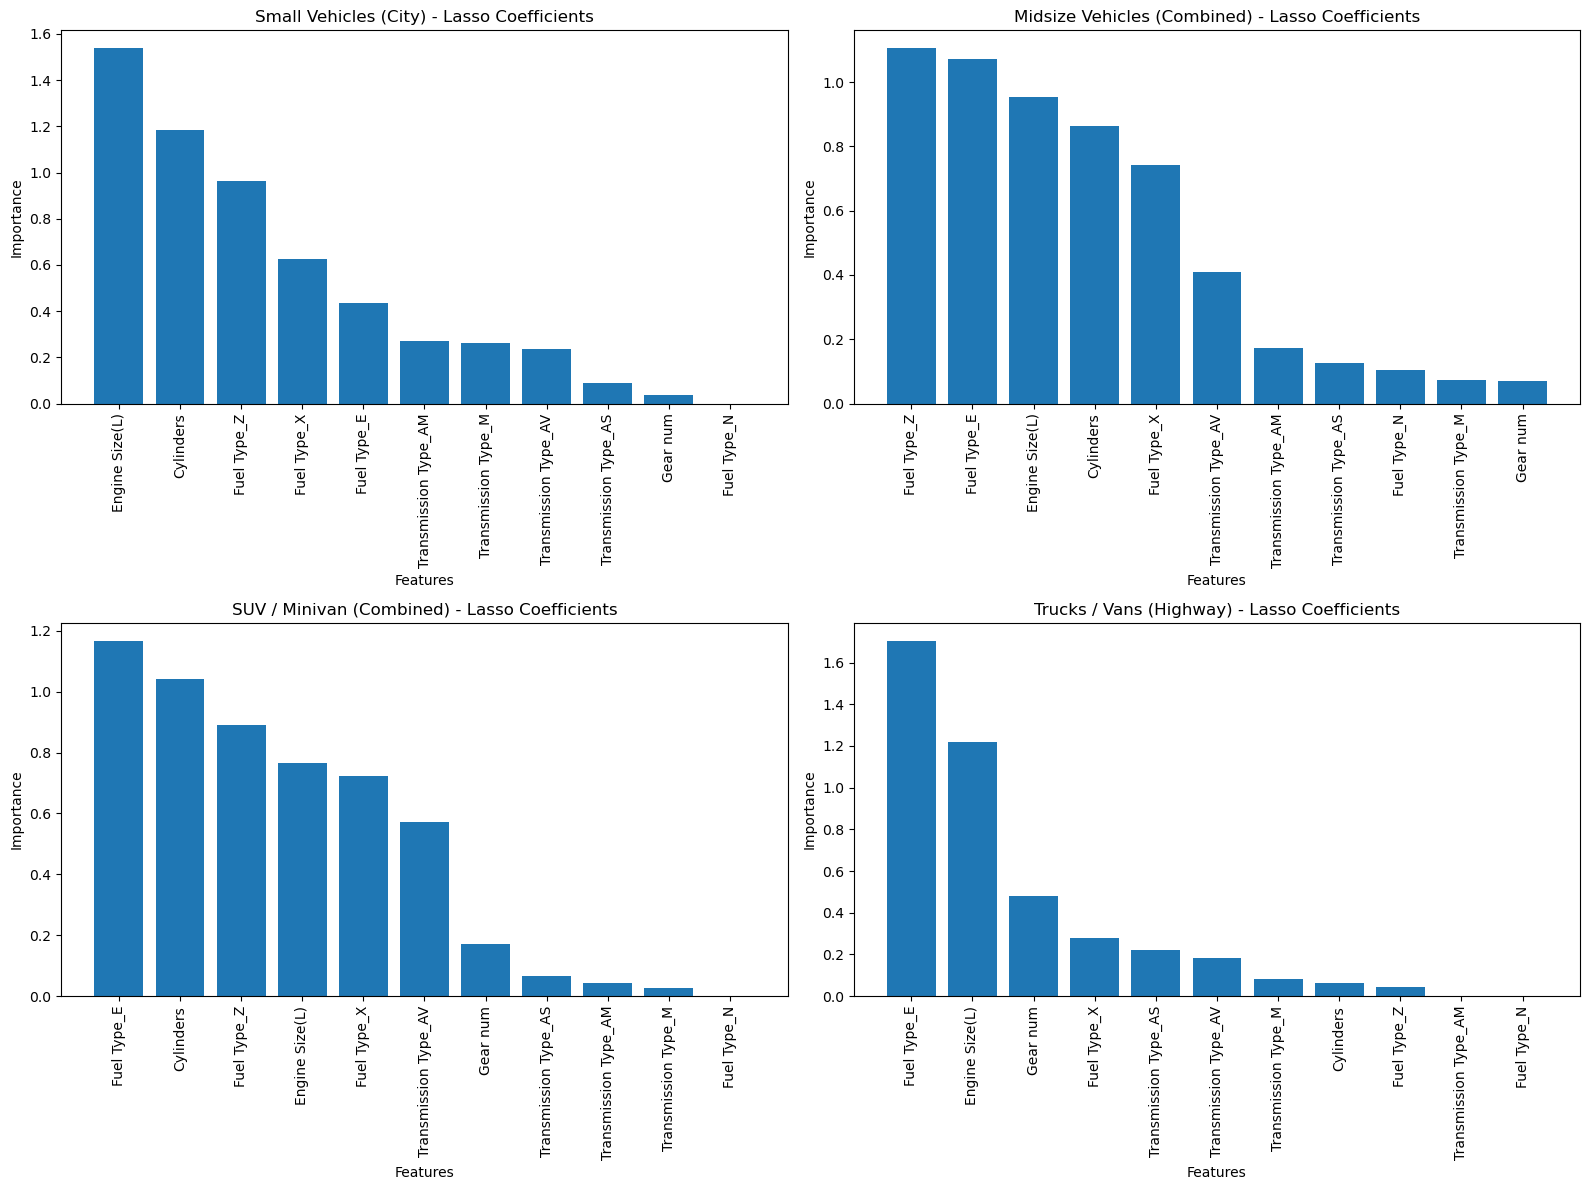

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Small Vehicles (City)
df_s = pd.DataFrame({
    'Feature': xs_train.columns,
    'Coefficients': np.abs(coef_small)
}).sort_values(by='Coefficients', ascending=False)

axes[0,0].bar(df_s['Feature'], df_s['Coefficients'])
axes[0,0].set_title("Small Vehicles (City) - Lasso Coefficients")
axes[0,0].set_xlabel("Features")
axes[0,0].set_ylabel("Importance")
axes[0,0].tick_params(axis='x', rotation=90)


# Middle Vehicles (Combined)
df_m = pd.DataFrame({
    'Feature': xm_train.columns,
    'Coefficients': np.abs(coef_middle)
}).sort_values(by='Coefficients', ascending=False)

axes[0,1].bar(df_m['Feature'], df_m['Coefficients'])
axes[0,1].set_title("Midsize Vehicles (Combined) - Lasso Coefficients")
axes[0,1].set_xlabel("Features")
axes[0,1].set_ylabel("Importance")
axes[0,1].tick_params(axis='x', rotation=90)


# SUV / Minivan (Combined)
df_v = pd.DataFrame({
    'Feature': xv_train.columns,
    'Coefficients': np.abs(coef_van)
}).sort_values(by='Coefficients', ascending=False)

axes[1,0].bar(df_v['Feature'], df_v['Coefficients'])
axes[1,0].set_title("SUV / Minivan (Combined) - Lasso Coefficients")
axes[1,0].set_xlabel("Features")
axes[1,0].set_ylabel("Importance")
axes[1,0].tick_params(axis='x', rotation=90)


# Trucks / Vans (Highway)
df_l = pd.DataFrame({
    'Feature': xl_train.columns,
    'Coefficients': np.abs(coef_large)
}).sort_values(by='Coefficients', ascending=False)

axes[1,1].bar(df_l['Feature'], df_l['Coefficients'])
axes[1,1].set_title("Trucks / Vans (Highway) - Lasso Coefficients")
axes[1,1].set_xlabel("Features")
axes[1,1].set_ylabel("Importance")
axes[1,1].tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()

#### RFE and lasso results:
Both RFE and Lasso give similar results in all four models.

Small Vehicles

Both Lasso and RFE indicate that engine size, number of cylinders, and type of fuel are the key factors that influence city fuel consumption. Fuel Type_N and Gear num don't seem to add much to the model, so they should be removed

Midsize

Lasso finds that fuel type A, fuel type E, engine size, and cylinders are the key factors that have the most influence. Even though some variables have smaller coefficients, RFE keeps all of them, meaning each one adds some useful information to the model.

SUV/Minivan

Lasso identifies fuel type, cylinders, and engine size as the top factors that are most important. Some transmission variables and the Fuel Type_N category have very small coefficients, but the RFE method still keeps all the features.

truck/van model

Both Lasso and RFE find that Fuel Type_E, engine size, and gear number are important factors in predicting highway fuel consumption. The transmission type AM and fuel type N have very small coefficients and are always considered to be less important features.



##Conclusion
#### Small Vehicles (City Model)
Features suggested for removal:
- **Fuel Type_N**
- **Gear num**
---
#### Midsize Vehicles (Combined Model)
**no features are removed for this model**.

---


#### SUV / Minivan (Combined Model)
**all features are kept for this model**.


---


#### Trucks / Vans (Highway Model)
Features suggested for removal:
- **Transmission Type_AM**
- **Fuel Type_N**



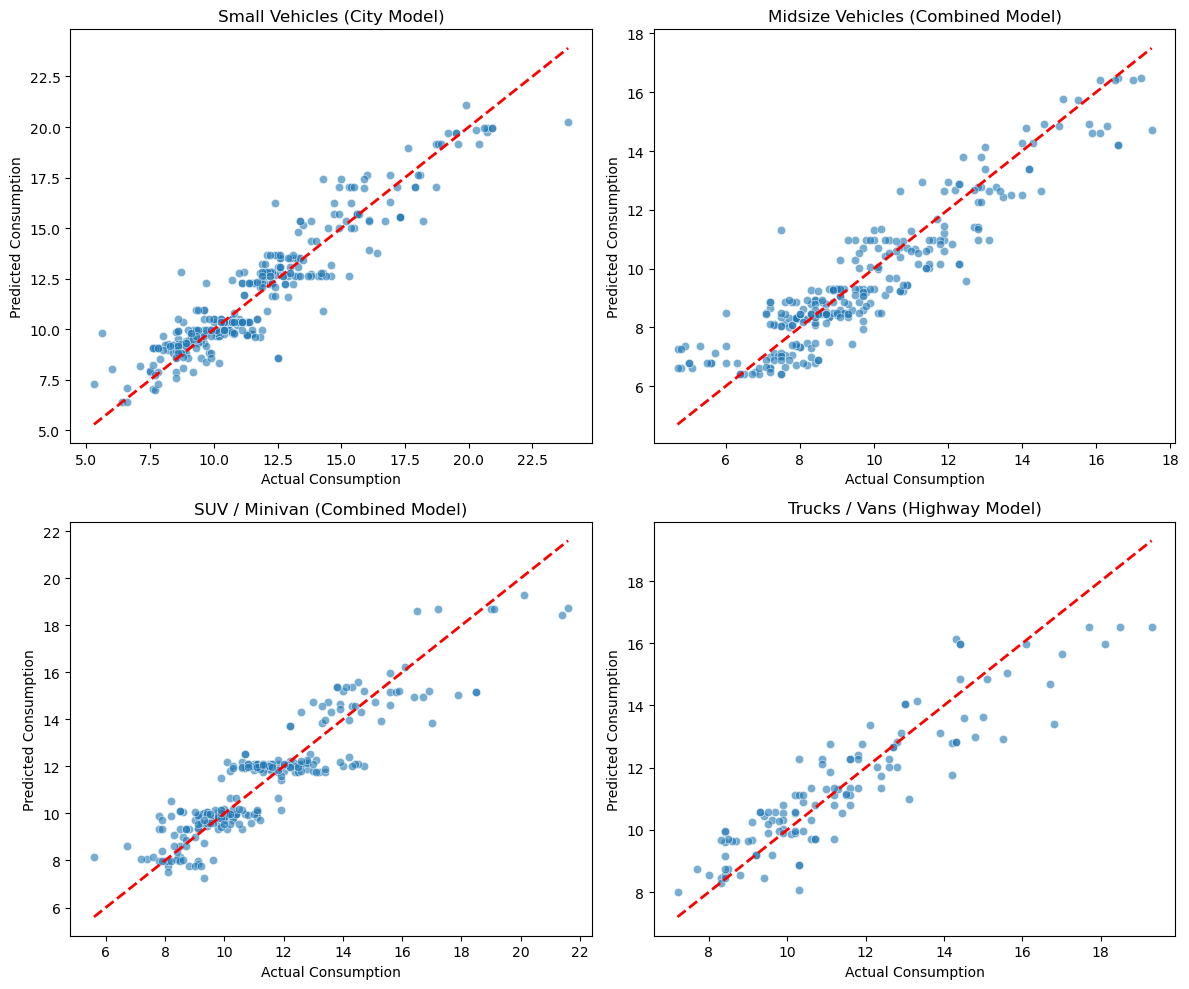

Prediction complete. Results successfully saved to 'clean_data_with_predictions.csv'!

Model Evaluation:
Small Vehicles -> R²: 0.840, RMSE: 1.288
Midsize Vehicles -> R²: 0.849, RMSE: 1.007
SUV / Minivan -> R²: 0.839, RMSE: 1.005
Trucks / Vans -> R²: 0.766, RMSE: 1.208


In [44]:

# Define a function to train the model, predict on all data, and plot the results
def train_predict_and_plot(X, y, drop_cols, title, ax):
    # Drop unnecessary features based on feature selection results
    X_selected = X.drop(columns=drop_cols, errors='ignore')
    
    # Split the data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
    
    # Initialize and fit the standard scaler on the training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Initialize and train the linear regression model
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    
    # Predict on the test set for visualization
    X_test_scaled = scaler.transform(X_test)
    y_test_pred = lr_model.predict(X_test_scaled)
    
    # Scale the entire dataset to generate final predictions
    X_all_scaled = scaler.transform(X_selected)
    y_all_pred = lr_model.predict(X_all_scaled)
    
    # --- Visualization: Actual vs Predicted ---
    ax.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='w', linewidth=0.5)
    
    # Plot the ideal y=x reference line (Red dashed line)
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    # Set plot labels and title
    ax.set_xlabel("Actual Consumption")
    ax.set_ylabel("Predicted Consumption")
    ax.set_title(title)
    
    # Return the predictions for the entire dataset as a Pandas Series with original indices
    return pd.Series(y_all_pred, index=X.index)


# Create a figure for the subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Small Vehicles (Drop 'Fuel Type_N' and 'Gear num')
pred_small = train_predict_and_plot(feat_small, city_small, ['Fuel Type_N', 'Gear num'], "Small Vehicles (City Model)", axes[0, 0])

# 2. Midsize Vehicles (Keep all features)
pred_middle = train_predict_and_plot(feat_middle, comb_middle, [], "Midsize Vehicles (Combined Model)", axes[0, 1])

# 3. SUV / Minivan (Keep all features)
pred_van = train_predict_and_plot(feat_van, comb_van, [], "SUV / Minivan (Combined Model)", axes[1, 0])

# 4. Trucks / Vans (Drop 'Transmission Type_AM' and 'Fuel Type_N')
pred_large = train_predict_and_plot(feat_large, hwy_large, ['Transmission Type_AM', 'Fuel Type_N'], "Trucks / Vans (Highway Model)", axes[1, 1])

# Adjust layout to prevent overlapping text and display the plots
plt.tight_layout()
plt.show()

# Concatenate all prediction series vertically into a single column
all_predictions = pd.concat([pred_small, pred_middle, pred_van, pred_large])

# Load the original clean dataset
df_clean = pd.read_csv('../Data/Clean dataset.csv')

# Align predictions by their original indices and add as a new column
df_clean['fuel_consumption_predict'] = all_predictions

# Save the updated dataset to a new CSV file
df_clean.to_csv('../Data/clean_data_with_predictions.csv', index=False)

# Print confirmation message
print("Prediction complete. Results successfully saved to 'clean_data_with_predictions.csv'!")

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("\nModel Evaluation:")

# Small Vehicles
r2_small = r2_score(city_small, pred_small)
rmse_small = np.sqrt(mean_squared_error(city_small, pred_small))
print(f"Small Vehicles -> R²: {r2_small:.3f}, RMSE: {rmse_small:.3f}")

# Midsize Vehicles
r2_mid = r2_score(comb_middle, pred_middle)
rmse_mid = np.sqrt(mean_squared_error(comb_middle, pred_middle))
print(f"Midsize Vehicles -> R²: {r2_mid:.3f}, RMSE: {rmse_mid:.3f}")

# SUV / Minivan
r2_van = r2_score(comb_van, pred_van)
rmse_van = np.sqrt(mean_squared_error(comb_van, pred_van))
print(f"SUV / Minivan -> R²: {r2_van:.3f}, RMSE: {rmse_van:.3f}")

# Trucks / Vans
r2_large = r2_score(hwy_large, pred_large)
rmse_large = np.sqrt(mean_squared_error(hwy_large, pred_large))
print(f"Trucks / Vans -> R²: {r2_large:.3f}, RMSE: {rmse_large:.3f}")

In [45]:
print("\nModel Parameters (Intercept and Coefficients):")

def print_model_params(X, y, drop_cols, title):
    # Apply the same feature selection as in the model
    X_selected = X.drop(columns=drop_cols, errors='ignore')
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X_scaled, y)
    
    # Print intercept
    print(f"\n{title}")
    print(f"Intercept (constant): {model.intercept_:.4f}")
    
    # Print coefficients
    coef_df = pd.DataFrame({
        "Feature": X_selected.columns,
        "Coefficient": model.coef_
    })
    
    coef_df["Importance"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values(by="Importance", ascending=False)
    
    print(coef_df)


# Print parameters for each model
print_model_params(feat_small, city_small, ['Fuel Type_N', 'Gear num'], "Small Vehicles (City Model)")
print_model_params(feat_middle, comb_middle, [], "Midsize Vehicles (Combined Model)")
print_model_params(feat_van, comb_van, [], "SUV / Minivan (Combined Model)")
print_model_params(feat_large, hwy_large, ['Transmission Type_AM', 'Fuel Type_N'], "Trucks / Vans (Highway Model)")


Model Parameters (Intercept and Coefficients):

Small Vehicles (City Model)
Intercept (constant): 11.7418
                Feature  Coefficient  Importance
0        Engine Size(L)     1.516553    1.516553
1             Cylinders     1.245435    1.245435
8           Fuel Type_Z     1.044738    1.044738
7           Fuel Type_X     0.702168    0.702168
6           Fuel Type_E     0.438729    0.438729
2  Transmission Type_AM     0.252133    0.252133
5   Transmission Type_M     0.249567    0.249567
4  Transmission Type_AV    -0.229319    0.229319
3  Transmission Type_AS     0.080152    0.080152

Midsize Vehicles (Combined Model)
Intercept (constant): 9.9455
                 Feature  Coefficient  Importance
10           Fuel Type_Z     1.169578    1.169578
7            Fuel Type_E     1.085861    1.085861
0         Engine Size(L)     0.963726    0.963726
1              Cylinders     0.848275    0.848275
9            Fuel Type_X     0.803349    0.803349
5   Transmission Type_AV    -0.394227  

In [46]:
df_small = feat_small.copy()

df_small["actual"] = city_small
df_small["predicted"] = pred_small
df_small["residual"] = df_small["actual"] - df_small["predicted"]

# top 10% most efficient vehicles
efficient_small = df_small.nsmallest(int(len(df_small)*0.1), "residual")

print("Small vehicle efficient features:")
print(efficient_small.mean())

Small vehicle efficient features:
Engine Size(L)           3.854878
Cylinders                6.628049
Gear num                 6.750000
Transmission Type_AM     0.280488
Transmission Type_AS     0.353659
Transmission Type_AV     0.091463
Transmission Type_M      0.170732
Fuel Type_E              0.000000
Fuel Type_N              0.000000
Fuel Type_X              0.158537
Fuel Type_Z              0.841463
actual                  11.464024
predicted               13.558482
residual                -2.094457
dtype: float64


In [47]:
df_mid = feat_middle.copy()

df_mid["actual"] = comb_middle
df_mid["predicted"] = pred_middle
df_mid["residual"] = df_mid["actual"] - df_mid["predicted"]

efficient_mid = df_mid.nsmallest(int(len(df_mid)*0.1), "residual")

print("Midsize vehicle efficient features:")
print(efficient_mid.mean())

Midsize vehicle efficient features:
Engine Size(L)          2.952143
Cylinders               5.271429
Gear num                5.721429
Transmission Type_AM    0.157143
Transmission Type_AS    0.471429
Transmission Type_AV    0.257143
Transmission Type_M     0.035714
Fuel Type_E             0.021429
Fuel Type_N             0.000000
Fuel Type_X             0.600000
Fuel Type_Z             0.378571
actual                  7.767143
predicted               9.602702
residual               -1.835559
dtype: float64


In [48]:
df_van = feat_van.copy()

df_van["actual"] = comb_van
df_van["predicted"] = pred_van
df_van["residual"] = df_van["actual"] - df_van["predicted"]

efficient_van = df_van.nsmallest(int(len(df_van)*0.1), "residual")

print("SUV/minivan efficient features:")
print(efficient_van.mean())

SUV/minivan efficient features:
Engine Size(L)           3.553906
Cylinders                6.000000
Gear num                 6.679688
Transmission Type_AM     0.007812
Transmission Type_AS     0.562500
Transmission Type_AV     0.171875
Transmission Type_M      0.015625
Fuel Type_E              0.046875
Fuel Type_N              0.000000
Fuel Type_X              0.515625
Fuel Type_Z              0.429688
actual                  10.363281
predicted               12.062333
residual                -1.699052
dtype: float64


In [49]:
df_van = feat_van.copy()

df_van["actual"] = comb_van
df_van["predicted"] = pred_van
df_van["residual"] = df_van["actual"] - df_van["predicted"]

efficient_van = df_van.nsmallest(int(len(df_van)*0.1), "residual")

print("SUV/minivan efficient features:")
print(efficient_van.mean())

SUV/minivan efficient features:
Engine Size(L)           3.553906
Cylinders                6.000000
Gear num                 6.679688
Transmission Type_AM     0.007812
Transmission Type_AS     0.562500
Transmission Type_AV     0.171875
Transmission Type_M      0.015625
Fuel Type_E              0.046875
Fuel Type_N              0.000000
Fuel Type_X              0.515625
Fuel Type_Z              0.429688
actual                  10.363281
predicted               12.062333
residual                -1.699052
dtype: float64


In [50]:
df_large = feat_large.copy()

df_large["actual"] = hwy_large
df_large["predicted"] = pred_large
df_large["residual"] = df_large["actual"] - df_large["predicted"]

efficient_large = df_large.nsmallest(int(len(df_large)*0.1), "residual")

print("Truck/van efficient features:")
print(efficient_large.mean())

Truck/van efficient features:
Engine Size(L)           4.375000
Cylinders                6.800000
Gear num                 6.183333
Transmission Type_AM     0.000000
Transmission Type_AS     0.416667
Transmission Type_AV     0.016667
Transmission Type_M      0.050000
Fuel Type_E              0.383333
Fuel Type_N              0.000000
Fuel Type_X              0.600000
Fuel Type_Z              0.016667
actual                  11.133333
predicted               12.810140
residual                -1.676806
dtype: float64
